# File Input and Output with Arrays

In [1]:
import numpy as np

In [2]:
# create array and save to binary file
arr = np.arange(10)
arr2= np.arange(15)

np.save('some_array', arr)
load_arr = np.load('some_array.npy')

# save multiple arrays to uncompressed
np.savez('array_archive.npz', a=arr, b=arr2)
arch = np.load('array_archive.npz')

list(arch.keys()) # ['a', 'b']
print(arch['b']) # access to keys
print(arch)
print(load_arr)
print("Are the array equal?", np.array_equal(arr, load_arr))

# Save multiple arrays to compressed archive
np.savez_compressed('arrays_compressed.npz', a=arr, b=arr)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
NpzFile 'array_archive.npz' with keys: a, b
[0 1 2 3 4 5 6 7 8 9]
Are the array equal? True


| Function | Description | File Extension |
|----------|-------------|----------------|
`np.save()`|	Save single array to binary file	|`.npy`
`np.load()`|Load array from .npy or .npz file	| `.npy`, `.npz`
`np.savez()`	|Save multiple arrays to uncompressed archive	| `.npz`
`np.savez_compressed()`|	Save multiple arrays to compressed archive	| `.npz`

Key Points:
- NumPy's binary format is efficient for numerical data
- `.npz` files act like dictionaries for multiple arrays
- Use compressed format when data compresses well


## Linear Algebra Operations

In [3]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])

B = np.array([[7, 8],
              [9, 10],
              [11, 12]])

# Multiplication
C1 = A.dot(B)                       # Matrix multiply
C2 = np.dot(A, B)                   # Same as above
C3 = A @ B                          # Modern syntax (Python 3.5+)
np.array_equal(C1, C2) and np.array_equal(C2, C3) # True

True

In [4]:
# Decomposition
# Create a symmetric matrix
matrix = np.array([[2, 1],
                   [1, 2]])

Q, R = np.linalg.qr(A)             # QR decomposition
U, S, V = np.linalg.svd(A)         # Singular Value Decomposition
vals, vecs = np.linalg.eig(matrix) # Eigen decomposition

# Properties
d = np.linalg.det(matrix)          # Determinant
trace = np.trace(matrix)           # Sum of diagonal

In [5]:
# Solving
# System of equations: x + 2y = 8 , 3x + y = 9

# In matrix form: A × X = B
a = np.array([[3, 1],              # Coefficients of x and y
              [1, 2]])             # from the equations

b = np.array([9, 8])               # Right-hand side values
x = np.linalg.solve(a, b)          # Solve Ax = b
x = np.linalg.lstsq(a, b)[0]       # Least squares solution
invA = np.linalg.inv(a)            # Matrix inverse (if exists)

| Operation | Syntax | Description |
|----------|---------|-------------|
Matrix Multiplication|	`x.dot(y)` or `np.dot(x, y)` or `x @ y`	|Standard matrix product `[a,b] @ [c,d]ᵀ = a*c + b*d`
Transpose	|`x.T` or `x.transpose()`|	Transpose of matrix
Inverse|	`np.linalg.inv(mat)`|	Matrix inverse
QR Decomposition|	`q, r = np.linalg.qr(mat)`	|Q (orthogonal) and R (upper triangular)
Determinant| `np.linalg.det(mat)`|	Matrix determinant
Eigenvalues/Vectors	| `np.linalg.eig(mat)`	|Eigen decomposition
SVD	| `np.linalg.svd(mat)`|	Singular Value Decomposition
Solve Linear System	| `np.linalg.solve(A, b)` |	Solve Ax = b

Important Notes:

- `*` operator performs element-wise multiplication, NOT matrix multiplication
- `@` operator available in Python 3.5+ for matrix multiplication
- NumPy uses optimized libraries (BLAS, LAPACK, MKL) for performance


### **Common numpy.linalg Functions**
| Function | Purpose | Example Use Case |
|----------|---------|------------------|
`inv()` |	Matrix inverse	| Solving linear equations
`qr()` |	QR decomposition |	Least squares problems
`svd()` |	Singular Value Decomposition |	Dimensionality reduction
`eig()` |	Eigen decomposition	| Principal Component Analysis
`det() `|	Determinant |	Checking invertibility
`solve()` |	Linear system solver |	Ax = b problems
`lstsq()` |	Least squares	| Regression problems
`pinv()` |	Pseudo-inverse |	Non-square matrices

### Common Patterns

In [6]:
# 1. Always check if matrix is square before inverting
if A.shape[0] == A.shape[1]:
    try:
        A_inv = np.linalg.inv(A)
    except np.linalg.LinAlg:
        print("Matrix is singular")

# 2. Use @ for clarity in matrix multiplicationresult = matrix1 @ matrix2  
# Clear this is matrix multiplication

In [7]:
# 3. For large arrays, use compressed format
if arr.nbytes >1_000_000:  # If larger than 1MB
    np.savez_compressed('large_data.npz', data=arr)

In [8]:
# 4. Verify decompositions
Q, R = np.linalg.qr(A)
reconstructed = Q @ R
error = np.max(np.abs(A - reconstructed))
print(f"Reconstruction error: {error}")  # Should be very small

Reconstruction error: 1.3322676295501878e-15


## Pseudorandom Number Generation

In [9]:
import numpy as np
from random import normalvariate
import time

# compare speed of random number generation

N = 1000000 # Number of sample

# Traditional python method
start = time.time()
sample_python = [normalvariate(0, 1) for _ in range(N)]
time_python = time.time() - start

# NumPy method
start = time.time()
sampke_numpy = np.random.normal(size=N)
time_numpy = time.time() - start

time_python , time_numpy 
# ~0.4       # 0.02

(0.7568597793579102, 0.04012703895568848)

In [10]:
# Set global seed
np.random.seed(42) # same output every run

# Generate samples
samples1 = np.random.normal(size=5)

# Better method: Create independent generator
rng = np.random.RandomState(42)  # Isolated generator
samples2 = rng.normal(size=5)

# Generate 3x4x2 array from normal distribution
samples_3d = np.random.normal(size=(3, 4, 2))


In [11]:
# Create random generator
rng = np.random.RandomState(42)

# Uniform distribution
uniform_samples = rng.uniform(low=0, high=10, size=1000)
# 1000 numbers between 0 and 10

# Normal distribution
normal_samples = rng.normal(loc=100, scale=15, size=1000)
# mean=100, std=15

# Binomial distribution
binomial_samples = rng.binomial(n=10, p=0.5, size=1000)
# 10 coin flips, p(heads)=0.5

# Random integers
integers = rng.randint(low=1, high=7, size=20)
# 20 numbers between 1 and 6 (like dice)

In [12]:
# Original array
arr = np.arange(10)  # [0, 1, 2, ..., 9]
print(arr)

# Create permutation (new copy)
permuted = np.random.permutation(arr)
print(permuted)

# Shuffle in-place
np.random.shuffle(arr)  # arr is modified directly
print(arr)

[0 1 2 3 4 5 6 7 8 9]
[8 5 1 7 0 2 4 9 6 3]
[2 0 4 9 8 6 7 5 1 3]


## NumPy Random functions Cheat Sheet

### **Basic Random Functions**
| Function | Description | Parameters | Example | Output |
|----------|-------------|------------|---------|--------|
`np.random.seed(seed)`|	Set global random seed	| `seed (int)`	| `seed(42)` |	-
`np.random.RandomState(seed)`|	Create independent generator	| `seed (int)` |	`rng = RandomState(42)`	| -
`np.random.permutation(arr)`|	Return shuffled copy	| `arr (array or int)` |	`permutation(10)` |	Same as input
`np.random.shuffle(arr)`|	Shuffle in-place|	`arr (array)`	| `shuffle(arr)`	|Modifies input
`np.random.rand(d0,d1,...,dn)`|	Uniform [0,1)	| Dimensions	|`rand(3, 4)`|	(3, 4)
`np.random.randn(d0,d1,...,dn)`|	Standard normal	Dimensions|	`randn(100)`|	`(100,)`|
`np.random.randint(low,high,size)`|	Random integers	low, high, size|	`randint(0, 10, 5)`	| `(5,)`

### **Distribution Functions**
| Function | Distribution | Parameters | Example | Use case |
|----------|--------------|-------------|---------|----------|
`np.random.uniform(low,high,size)` |	Uniform	|` low, high, size`|	`uniform(0, 1, 100)`|	Random sampling
`np.random.normal(loc,scale,size)`	| Normal/Gaussian	|`loc, scale, size` |	`normal(0, 1, 1000)`|	Natural phenomena
`np.random.binomial(n,p,size)`|	Binomial|	`n, p, size`	|`binomial(10, 0.5, 100)` |	Success/failure
`np.random.beta(a,b,size)`|	Beta|	`a, b, size`|	`beta(2, 5, 100)`|	Probabilities
`np.random.chisquare(df,size)`	|Chi-square	|`df, size`	|`chisquare(3, 100)`|	Hypothesis testing
`np.random.gamma(shape,scale,size)`|	Gamma	|`shape, scale, size`	|`gamma(2, 2, 100)`|	Wait times

### **Parameter Explanations**
| Parameter |  Description  |  Common Values  |	Example |
|-----------|---------------|-----------------|---------|
`size` |	Output shape|	int or tuple|	`size=100` or `size=(10, 20)`
`loc`	|Mean (center)|	Any real number	|`loc=0` (centered)
`scale`	|Standard deviation|	Positive number|	`scale=1` (unit variance)
`low/high`|	Range boundaries	|`low < high`|	`low=0, high=1`
`n, p`|	Binomial parameters|	`n>0, 0≤p≤1`|	`n=10, p=0.5`
`a, b`|	Beta shape parameters|	Positive numbers|	`a=2, b=5`
`df`	|Degrees of freedom	|Positive integer|	`df=3`

### **Common Mistakes & Solutions**
|Mistake|	Problem|	Solution|
|-------|----------|------------|
Using `shuffle` instead of `permutation`|	Modifies original array	|Use `permutation` for copy
Not setting seed|	Non-reproducible results|	Always set seed in experiments
Generating small batches in loop|	Slow performance	|Generate all at once
Using global random state|	Thread-unsafe|	Create local RandomState


## Random Walks
> Let’s first consider a simple random walk starting at 0 with steps of 1 and –1 occurring with equal probability.

In [13]:
# Traditional method with for loop
import random

position = 0 # starting position
walk = [position] # store path
steps = 1000

for i in range(steps):
    step = 1 if random.randint(0, 1) else -1
    position += step
    walk.append(position)

len(walk), walk[-1] # number of steps, final position

# problem: it's low for big data and simulation

(1001, 76)

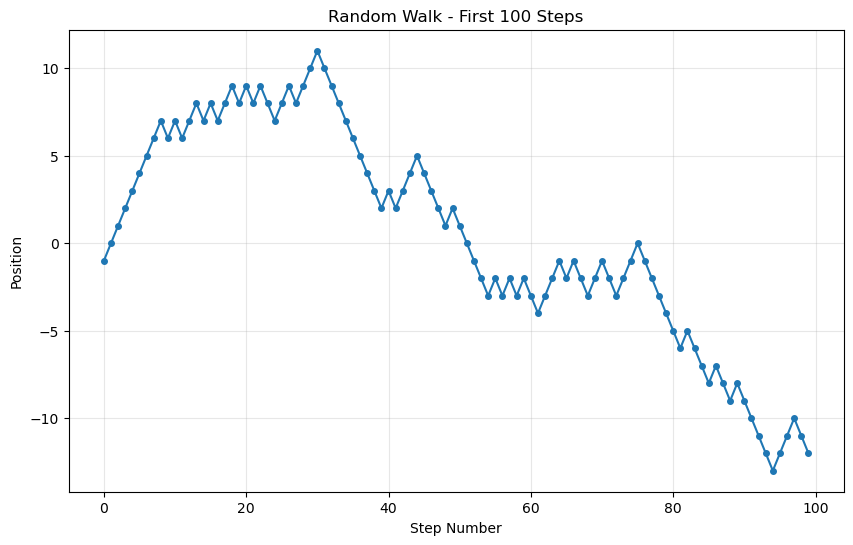

In [14]:
# NumPy method
import matplotlib.pyplot as plt

# Generate random 0s and 1s
draws = np.random.randint(0, 2, size=1000) # array of 0 and 1

# Convert to 1 and -1
steps = np.where(draws > 0, 1, -1)

# Calculate cumulative sum
walk = steps.cumsum() 

# Plot first 100 steps
plt.figure(figsize=(10, 6))
plt.plot(walk[:100], marker='o', linestyle='-', markersize=4)
plt.title('Random Walk - First 100 Steps')
plt.xlabel('Step Number')
plt.ylabel('Position')
plt.grid(True, alpha=0.3)
plt.show()